# **Prediksi Saham BBCA menggunakan LSTM**
# 0.Import Library

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import kagglehub, os, math
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import Dense, LSTM
from sklearn.metrics import mean_absolute_error

d:\Machine Learning\PrediksiSahamIDX\predsaham\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1.Load Dataset

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("muamkh/ihsgstockdata", output_dir="./dataset")

print("Path to dataset files:", path)

Path to dataset files: ./dataset


In [3]:
saham_df = pd.read_csv("dataset/DaftarSaham.csv")
saham_df[saham_df["Code"] == "BBCA"]

,Code,Name,ListingDate,Shares,ListingBoard,Sector,LastPrice,MarketCap,MinutesFirstAdded,MinutesLastUpdated,HourlyFirstAdded,HourlyLastUpdated,DailyFirstAdded,DailyLastUpdated
82,BBCA,Bank Central Asia Tbk.,2000-05-31,1.220423e+11,Utama,Financials,8300.0,1.012951e+15,2021-11-01 09:00:00,2023-01-06 15:59:00,2020-04-16 09:00:00,2023-01-06 15:00:00,2001-04-16,2023-01-06


In [4]:
bbca_df = pd.read_csv("dataset/daily/BBCA.csv")
bbca_df["timestamp"] = pd.to_datetime(bbca_df["timestamp"])
bbca_df.set_index("timestamp")

,open,low,high,close,volume
timestamp,,,,,
2001-04-16,175,175,180,177,0
2001-04-17,175,175,180,177,0
2001-04-18,175,175,180,177,0
2001-04-19,175,175,180,177,0
2001-04-20,175,175,180,177,0
...,...,...,...,...,...
2023-01-02,8575,8500,8600,8550,10653900
2023-01-03,8550,8525,8600,8550,27399100
2023-01-04,8525,8350,8575,8350,90918800


# 2.Exploratory Data Analysis

In [5]:
bbca_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5670 entries, 0 to 5669
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  5670 non-null   datetime64[us]
 1   open       5670 non-null   int64         
 2   low        5670 non-null   int64         
 3   high       5670 non-null   int64         
 4   close      5670 non-null   int64         
 5   volume     5670 non-null   int64         
dtypes: datetime64[us](1), int64(5)
memory usage: 265.9 KB


In [6]:
bbca_df.describe()

,timestamp,open,low,high,close,volume
count,5670,5670.000000,5670.000000,5670.000000,5670.000000,5.670000e+03
mean,2012-02-25 12:00:00,2418.109877,2393.385538,2442.639506,2418.603175,8.919048e+07
min,2001-04-16 00:00:00,175.000000,175.000000,177.000000,177.000000,0.000000e+00
25%,2006-09-20 06:00:00,460.000000,455.000000,467.000000,460.500000,2.719000e+07
50%,2012-02-25 12:00:00,1585.000000,1570.000000,1600.000000,1585.000000,6.161450e+07
75%,2017-08-01 18:00:00,3743.750000,3715.000000,3765.000000,3740.000000,1.045481e+08
max,2023-01-06 00:00:00,9050.000000,8975.000000,9400.000000,9300.000000,1.949960e+09
std,NaN,2379.071545,2357.118837,2400.150856,2378.798150,1.274925e+08


In [7]:
miss_val = bbca_df.isna().sum()
persentase = ((miss_val / len(bbca_df)) * 100).round(2)

missing = pd.DataFrame({
    "Missing Value": miss_val,
    "Persentase": persentase
})

missing

,Missing Value,Persentase
timestamp,0,0.0
open,0,0.0
low,0,0.0
high,0,0.0
close,0,0.0
volume,0,0.0


In [8]:
duplicated = bbca_df.duplicated().sum()
duplicated

np.int64(0)

In [9]:
features = ["open", "low", "high", "close", "volume"]

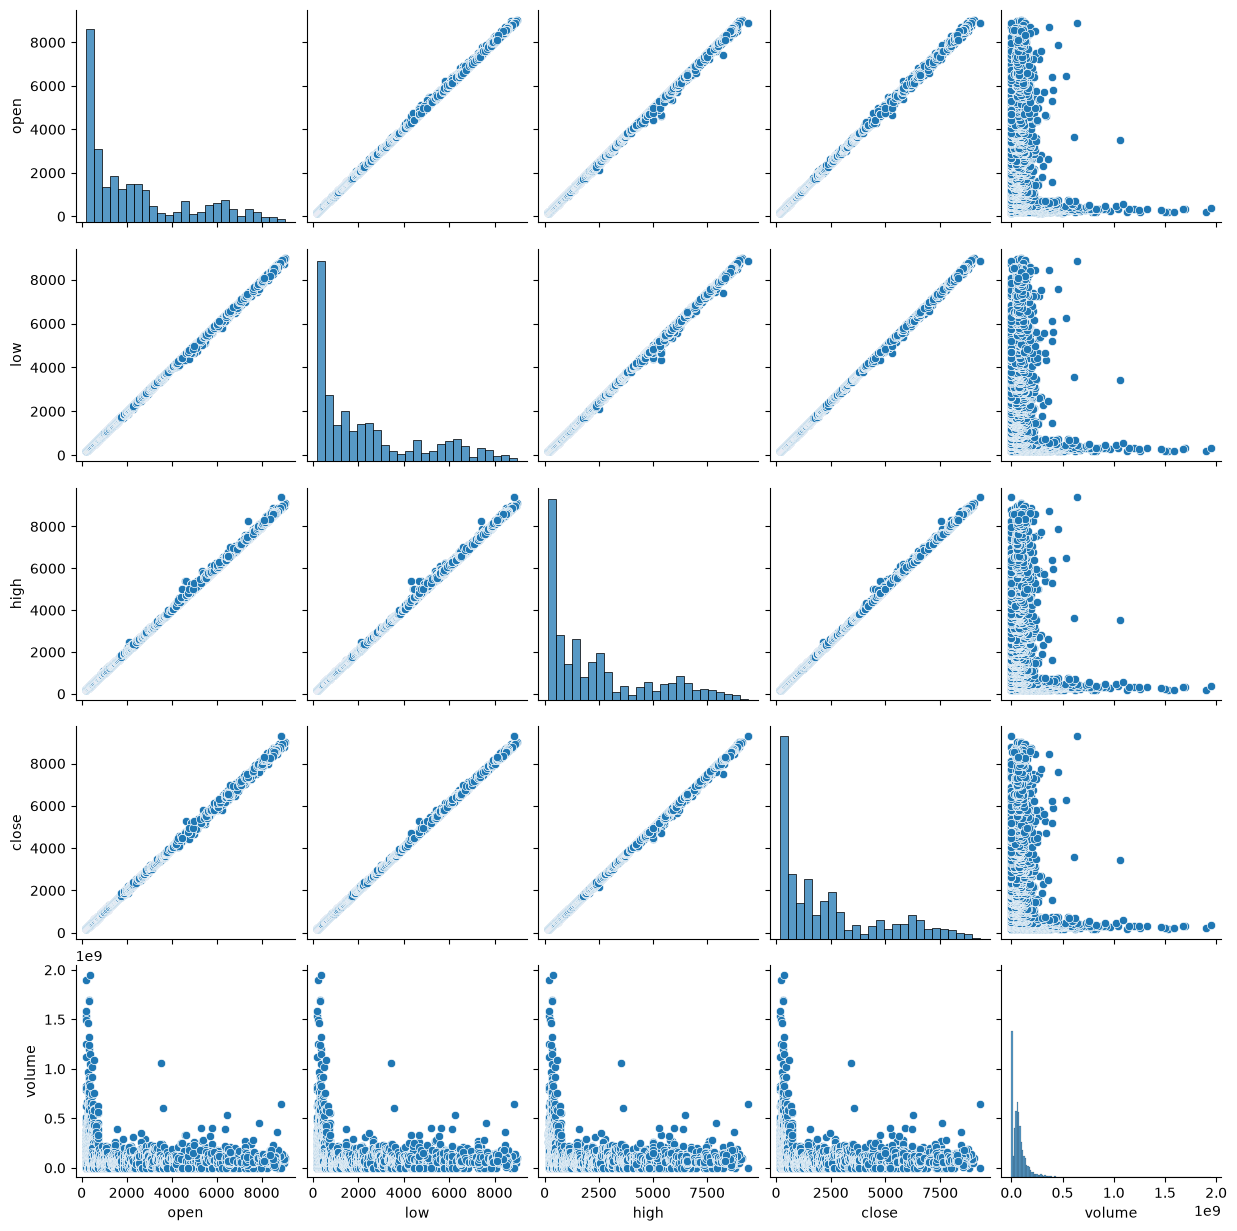

In [10]:
sns.pairplot(bbca_df[features])

Text(0.5, 1.0, 'Corrleation Matrix')

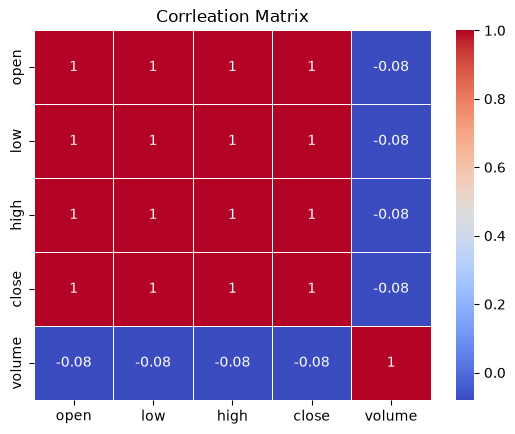

In [11]:
sns.heatmap(
    bbca_df[features].corr().round(2),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
)
plt.title("Corrleation Matrix")

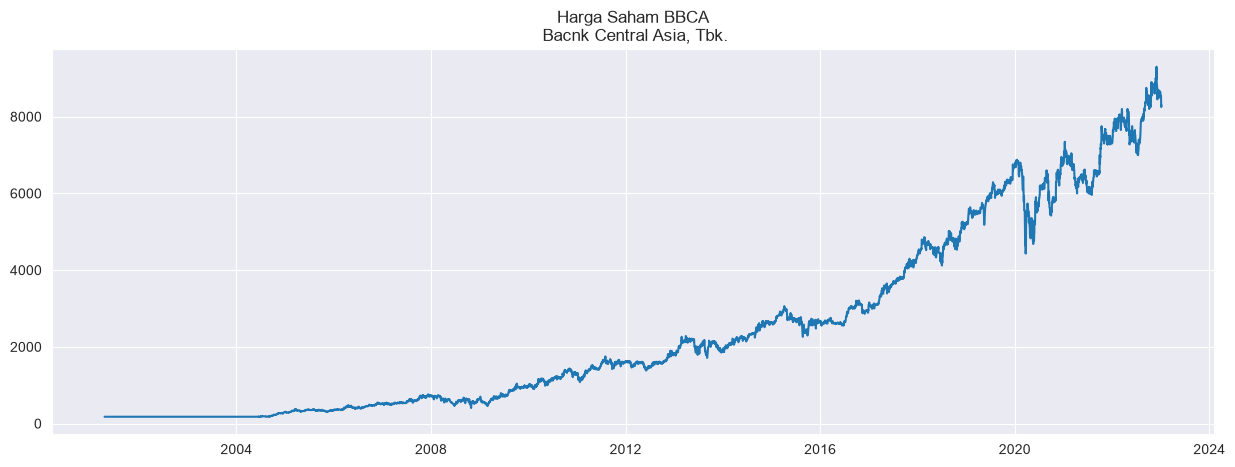

In [12]:
plt.figure(figsize=(15, 5))
sns.set_style("darkgrid")   
plt.plot(bbca_df["timestamp"], bbca_df["close"])
plt.title("Harga Saham BBCA\n Bacnk Central Asia, Tbk.")
plt.show()

# 3.Feature Engineering

In [13]:
def extract_timestamp(dataset):
    dataset["year"] = dataset["timestamp"].dt.year
    dataset["month"] = dataset["timestamp"].dt.month
    dataset["quarter"] = dataset["timestamp"].dt.quarter
    dataset["month_sin"] = np.sin(2 * np.pi * dataset["month"] / 12)
    dataset["month_cos"] = np.cos(2 * np.pi * dataset["month"] / 12)

    return dataset

In [14]:
extract_timestamp(bbca_df)

,timestamp,open,low,high,close,volume,year,month,quarter,month_sin,month_cos
0,2001-04-16,175,175,180,177,0,2001,4,2,0.866025,-0.500000
1,2001-04-17,175,175,180,177,0,2001,4,2,0.866025,-0.500000
2,2001-04-18,175,175,180,177,0,2001,4,2,0.866025,-0.500000
3,2001-04-19,175,175,180,177,0,2001,4,2,0.866025,-0.500000
4,2001-04-20,175,175,180,177,0,2001,4,2,0.866025,-0.500000
...,...,...,...,...,...,...,...,...,...,...,...
5665,2023-01-02,8575,8500,8600,8550,10653900,2023,1,1,0.500000,0.866025
5666,2023-01-03,8550,8525,8600,8550,27399100,2023,1,1,0.500000,0.866025
5667,2023-01-04,8525,8350,8575,8350,90918800,2023,1,1,0.500000,0.866025
5668,2023-01-05,8350,8150,8375,8250,128838500,2023,1,1,0.500000,0.866025


# 4.Data Preprocessing

In [15]:
train_size = int(len(bbca_df) * 0.8)
train, test = bbca_df[:train_size], bbca_df[train_size:]

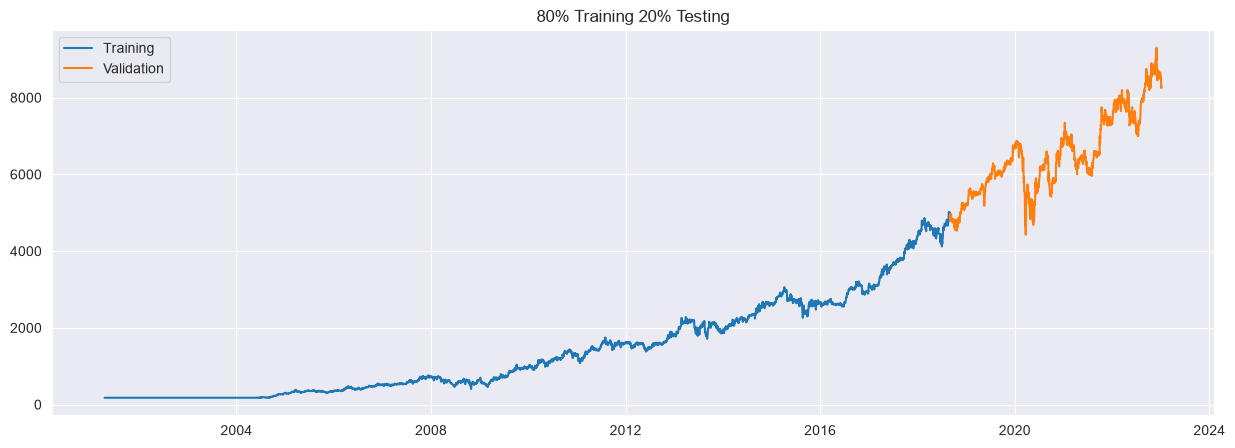

In [16]:
plt.figure(figsize=(15, 5))
plt.plot(train["timestamp"], train["close"], label="Training")
plt.plot(test["timestamp"], test["close"], label="Validation")
plt.legend(labels=["Training", "Validation"])
plt.title("80% Training 20% Testing")
plt.show()

In [17]:
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train[features])
test_scaled = scaler.transform(test[features])

In [18]:
train_scaled

array([[0.00000000e+00, 0.00000000e+00, 6.10004067e-04, 0.00000000e+00,
        0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 6.10004067e-04, 0.00000000e+00,
        0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 6.10004067e-04, 0.00000000e+00,
        0.00000000e+00],
       ...,
       [9.94840041e-01, 1.00000000e+00, 9.86783245e-01, 1.00000000e+00,
        4.93720384e-02],
       [9.95872033e-01, 9.94802495e-01, 9.82716551e-01, 9.88631666e-01,
        5.72129685e-02],
       [9.97936017e-01, 9.86486486e-01, 9.83733225e-01, 9.87598181e-01,
        1.97386100e-02]], shape=(4536, 5))

In [19]:
test_scaled

array([[0.98864809, 0.98232848, 0.97661651, 0.9865647 , 0.02167814],
       [0.9752322 , 0.94698545, 0.96034974, 0.95556015, 0.04903101],
       [0.95562436, 0.94490644, 0.98881659, 0.98449773, 0.04885485],
       ...,
       [1.72342621, 1.6995842 , 1.70760472, 1.68933444, 0.04662598],
       [1.6873065 , 1.65800416, 1.66693778, 1.66866474, 0.06607238],
       [1.63570691, 1.64760915, 1.65677105, 1.67899959, 0.03553232]],
      shape=(1134, 5))

In [20]:
def windowed_dataset(dataset, window_size, batch_size):
    ds = tf.data.Dataset.from_tensor_slices(dataset)
    ds = ds.window(window_size + 1, shift=1, drop_remainder=True)
    ds = ds.flat_map(lambda w: w.batch(window_size + 1))
    ds = ds.map(lambda w: (w[:-1], w[-1:]))

    return ds.batch(batch_size).prefetch(1)

In [21]:
train_set = windowed_dataset(train_scaled, window_size=1, batch_size=100)
test_set = windowed_dataset(test_scaled, window_size=1, batch_size=100)

# 5.Modeling

In [22]:
window_size = 1
len_features = len(features)

model = Sequential()
model.add(LSTM(100, input_shape=(window_size, len_features), return_sequences=True))
model.add(LSTM(50))
model.add(Dense(25, activation="relu"))
model.add(Dense(len_features))

d:\Machine Learning\PrediksiSahamIDX\predsaham\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [23]:
class Callback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if logs.get("val_mae") is not None and logs.get("val_mae") < 0.055:
            self.model.stop_training = True

In [24]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, metrics=["mae"], loss=tf.keras.losses.Huber())
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 100)         │        42,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,005 (289.08 KB)

 Trainable params: 74,005 (289.08 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
history = model.fit(
    train_set, 
    validation_data=test_set, 
    epochs=500,
    batch_size=128,  
    shuffle=False, 
    callbacks=[Callback()]
)

Epoch 1/500
     44/Unknown 2s 4ms/step - loss: 0.0411 - mae: 0.1882   

d:\Machine Learning\PrediksiSahamIDX\predsaham\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0492 - mae: 0.2038 - val_loss: 0.6236 - val_mae: 1.0279
Epoch 2/500
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0459 - mae: 0.1944 - val_loss: 0.6039 - val_mae: 1.0072
Epoch 3/500
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0426 - mae: 0.1867 - val_loss: 0.5802 - val_mae: 0.9852
Epoch 4/500
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0391 - mae: 0.1791 - val_loss: 0.5503 - val_mae: 0.9582
Epoch 5/500
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0351 - mae: 0.1712 - val_loss: 0.5122 - val_mae: 0.9232
Epoch 6/500
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0307 - mae: 0.1630 - val_loss: 0.4646 - val_mae: 0.8777
Epoch 7/500
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0262 - mae: 0.1542 - val_loss: 0.4075 - val_mae: 0.8200
Epoch 8/500
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0217 - mae: 0.1452 - val_loss: 0.3435 - val_mae: 0.7506
Epoch 9/500
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0176 - mae: 0.

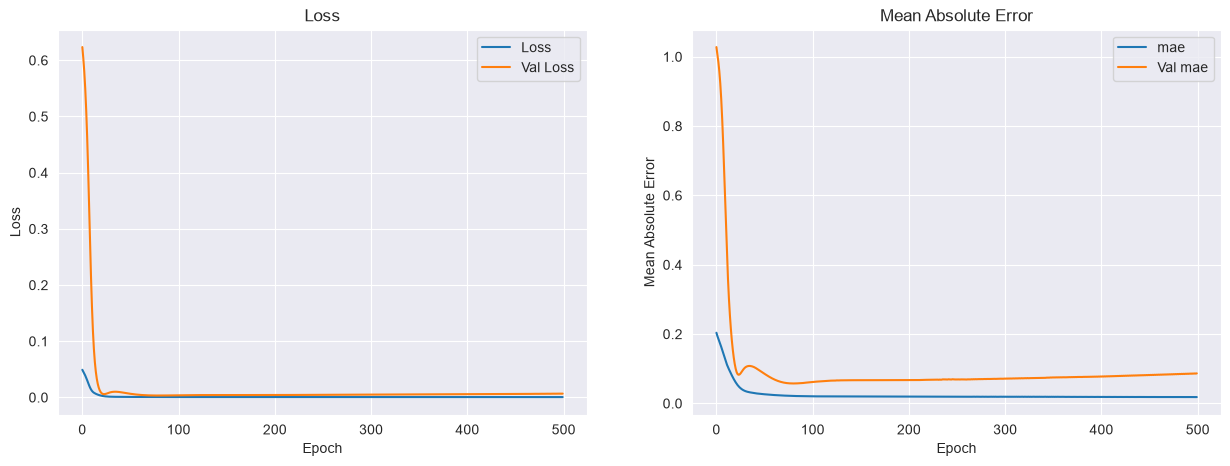

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss
ax1.plot(history.history["loss"]) 
ax1.plot(history.history["val_loss"])
ax1.legend(["Loss", "Val Loss"]) 
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss")

# MAE
ax2.plot(history.history["mae"])
ax2.plot(history.history["val_mae"])
ax2.legend(["mae", "Val mae"])
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Mean Absolute Error")
ax2.set_title("Mean Absolute Error")
plt.show()

In [28]:
pred = model.predict(test_set)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


d:\Machine Learning\PrediksiSahamIDX\predsaham\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [29]:
pred

array([[0.97366655, 0.975342  , 0.9650635 , 0.9762458 , 0.0437486 ],
       [0.95279324, 0.9528359 , 0.94243354, 0.95467854, 0.04301591],
       [0.9595164 , 0.9597996 , 0.94909924, 0.9619302 , 0.04341167],
       ...,
       [1.5133921 , 1.5112033 , 1.4814428 , 1.5437924 , 0.09036569],
       [1.4994177 , 1.496541  , 1.4651355 , 1.528617  , 0.08720356],
       [1.4787716 , 1.475562  , 1.4437264 , 1.5063435 , 0.08406992]],
      shape=(1133, 5), dtype=float32)

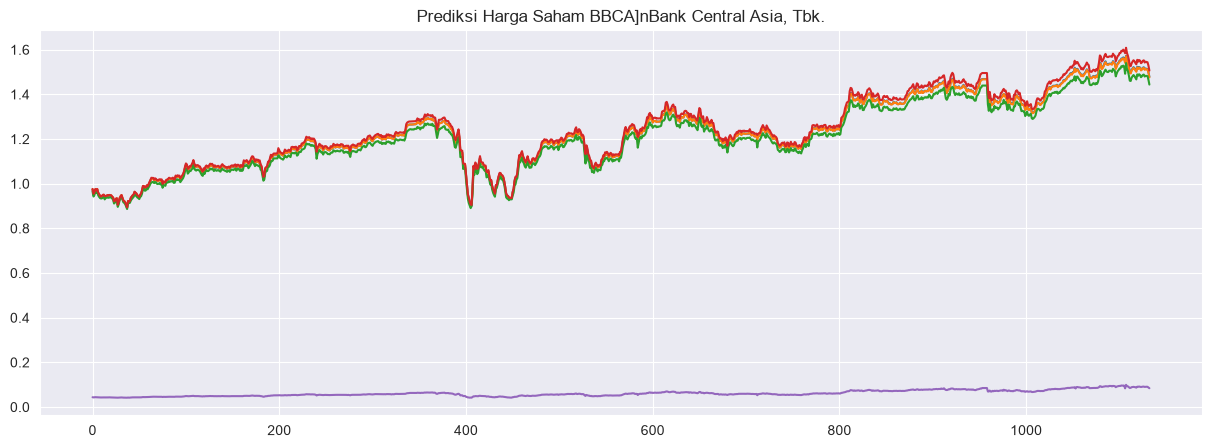

In [34]:
plt.figure(figsize=(15, 5))
plt.plot(pred)
plt.title("Prediksi Harga Saham BBCA]nBank Central Asia, Tbk.")
plt.show()

In [36]:
model.save("bbca_forecast_model.h5")